# Step 6: Causal Inference & Counterfactual Molecular Design

**Goal:** Move from *'What properties does this molecule have?'* to *'How do we build molecules with the properties we want?'*

| Section | What it does |
|---|---|
| 1 | Extract meaningful chemical features from each molecule |
| 2 | Draw a causal graph showing what drives HOMO / LUMO / Bandgap |
| 3 | Measure the true causal effect of each feature (controlling for confounders) |
| 4 | Counterfactual: *what would change if I modified this part of the molecule?* |
| 5 | Inverse design: given a target bandgap, find the best structural change |


In [ ]:
!apt-get install -qq graphviz libgraphviz-dev 2>/dev/null
!pip install dowhy networkx pandas numpy matplotlib scikit-learn xgboost rdkit -q
print('Libraries ready')


Selecting previously unselected package libatk1.0-data.
(Reading database ... 122354 files and directories currently installed.)
Preparing to unpack .../00-libatk1.0-data_2.36.0-3build1_all.deb ...
Unpacking libatk1.0-data (2.36.0-3build1) ...
Selecting previously unselected package libatk1.0-0:amd64.
Preparing to unpack .../01-libatk1.0-0_2.36.0-3build1_amd64.deb ...
Unpacking libatk1.0-0:amd64 (2.36.0-3build1) ...
Selecting previously unselected package libgtk2.0-common.
Preparing to unpack .../02-libgtk2.0-common_2.24.33-2ubuntu2.1_all.deb ...
Unpacking libgtk2.0-common (2.24.33-2ubuntu2.1) ...
Selecting previously unselected package libxcomposite1:amd64.
Preparing to unpack .../03-libxcomposite1_1%3a0.4.5-1build2_amd64.deb ...
Unpacking libxcomposite1:amd64 (1:0.4.5-1build2) ...
Selecting previously unselected package libgtk2.0-0:amd64.
Preparing to unpack .../04-libgtk2.0-0_2.24.33-2ubuntu2.1_amd64.deb ...
Unpacking libgtk2.0-0:amd64 (2.24.33-2ubuntu2.1) ...
Selecting previously u

In [ ]:
from google.colab import files
print('Upload: Data_Final_merged.xlsx, features_morgan.npy, models_rf.pkl')
uploaded = files.upload()


Upload: Data_Final_merged.xlsx, features_morgan.npy, models_rf.pkl


Saving models_rf.pkl to models_rf.pkl
Saving features_morgan.npy to features_morgan.npy
Saving Data_Final_merged.xlsx to Data_Final_merged.xlsx


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import pickle, warnings
warnings.filterwarnings('ignore')
from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors, rdMolDescriptors
from dowhy import CausalModel

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.grid': True, 'grid.alpha': 0.3,
    'font.size': 12, 'axes.titlesize': 14, 'axes.titleweight': 'bold',
    'axes.labelsize': 12, 'xtick.labelsize': 11, 'ytick.labelsize': 11,
})
print('Imports done')


Imports done


In [ ]:
# Section 1 — Extract chemical features
# Each feature has a known chemical reason for affecting electronic properties.

df = pd.read_excel('Data_Final_merged.xlsx')

def extract_features(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    total_C = sum(1 for a in mol.GetAtoms() if a.GetAtomicNum() == 6)
    sp2_C   = sum(1 for a in mol.GetAtoms()
                 if a.GetAtomicNum() == 6 and a.GetHybridization().name == 'SP2')
    return {
        'conjugation': (sp2_C / total_C) if total_C > 0 else 0,
        'aromaticity': sum(1 for a in mol.GetAtoms() if a.GetIsAromatic()) / mol.GetNumAtoms(),
        'ewg_count':   (len(mol.GetSubstructMatches(Chem.MolFromSmarts('[N+](=O)[O-]'))) +
                        len(mol.GetSubstructMatches(Chem.MolFromSmarts('C#N'))) +
                        len(mol.GetSubstructMatches(Chem.MolFromSmarts('C=O'))) +
                        sum(1 for a in mol.GetAtoms() if a.GetAtomicNum() in [9,17,35,53])),
        'edg_count':   (len(mol.GetSubstructMatches(Chem.MolFromSmarts('N'))) +
                        len(mol.GetSubstructMatches(Chem.MolFromSmarts('OC')))),
        'n_rings':     rdMolDescriptors.CalcNumRings(mol),
        'mol_weight':  Descriptors.MolWt(mol),
        'heteroatoms': sum(1 for a in mol.GetAtoms()
                          if a.GetAtomicNum() in [7,8,16]) / mol.GetNumAtoms(),
    }

rows, idx = [], []
for i, smi in enumerate(df['SMILES_acc']):
    f = extract_features(smi)
    if f:
        rows.append(f)
        idx.append(i)

feat_df   = pd.DataFrame(rows)
df_causal = pd.concat(
    [df.iloc[idx][['SMILES_acc','HOMO_A','LUMO_A','EgA_opt']].reset_index(drop=True),
     feat_df.reset_index(drop=True)], axis=1)

print(f'{len(df_causal)} molecules | 7 features extracted')
print()
print(feat_df.describe().loc[['mean','std','min','max']].round(3).to_string())


1571 molecules | 7 features extracted

      conjugation  aromaticity  ewg_count  edg_count  n_rings  mol_weight  heteroatoms
mean        0.605        0.473      8.649      4.348   13.480    1455.774        0.139
std         0.143        0.110      2.615      1.406    3.361     411.736        0.038
min         0.323        0.194      0.000      0.000    5.000     432.552        0.061
max         0.917        0.809     24.000     13.000   40.000    5592.602        0.333


Saved: causal_graph.png


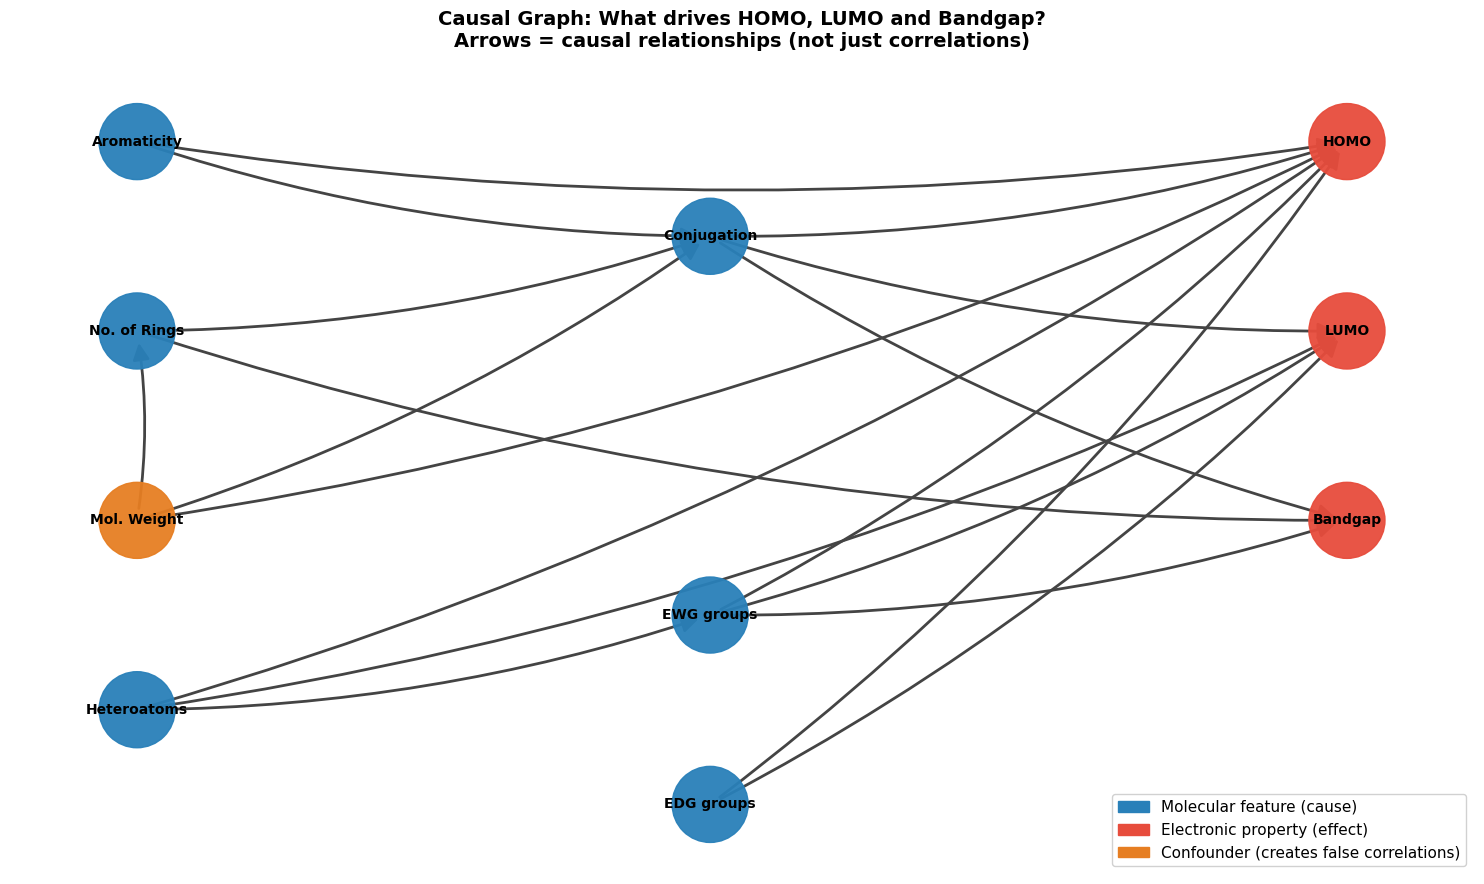

In [ ]:
# Section 2 — Causal graph
# Arrows = causal relationships from chemistry knowledge, NOT learned from data.

G = nx.DiGraph()
G.add_edges_from([
    ('Conjugation',  'HOMO'),  ('Conjugation',  'LUMO'),  ('Conjugation',  'Bandgap'),
    ('Aromaticity',  'Conjugation'), ('Aromaticity', 'HOMO'),
    ('No. of Rings', 'Conjugation'), ('No. of Rings', 'Bandgap'),
    ('EWG groups',   'HOMO'),  ('EWG groups',   'LUMO'),  ('EWG groups',   'Bandgap'),
    ('EDG groups',   'HOMO'),  ('EDG groups',   'LUMO'),
    ('Heteroatoms',  'HOMO'),  ('Heteroatoms',  'LUMO'),  ('Heteroatoms',  'EWG groups'),
    ('Mol. Weight',  'Conjugation'), ('Mol. Weight', 'No. of Rings'), ('Mol. Weight', 'HOMO'),
])

pos = {
    'Mol. Weight':  (0.0, 0.5),  'Aromaticity':  (0.0, 2.5),
    'No. of Rings': (0.0, 1.5),  'Conjugation':  (1.8, 2.0),
    'Heteroatoms':  (0.0, -0.5), 'EWG groups':   (1.8, 0.0),
    'EDG groups':   (1.8, -1.0), 'HOMO':         (3.8, 2.5),
    'LUMO':         (3.8, 1.5),  'Bandgap':      (3.8, 0.5),
}

outcomes   = ['HOMO','LUMO','Bandgap']
confounder = ['Mol. Weight']
node_colors = [
    '#e74c3c' if n in outcomes else
    '#e67e22' if n in confounder else '#2980b9'
    for n in G.nodes()
]

fig, ax = plt.subplots(figsize=(15, 9))
fig.patch.set_facecolor('white')
ax.set_facecolor('#f8f9fa')
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=3000, ax=ax, alpha=0.95)
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold', ax=ax)
nx.draw_networkx_edges(G, pos, ax=ax, edge_color='#444', arrows=True,
                       arrowsize=25, width=2.0, connectionstyle='arc3,rad=0.08')
ax.legend(handles=[
    mpatches.Patch(color='#2980b9', label='Molecular feature (cause)'),
    mpatches.Patch(color='#e74c3c', label='Electronic property (effect)'),
    mpatches.Patch(color='#e67e22', label='Confounder (creates false correlations)'),
], loc='lower right', fontsize=11, framealpha=0.9)
ax.set_title('Causal Graph: What drives HOMO, LUMO and Bandgap?\nArrows = causal relationships (not just correlations)', pad=18)
ax.axis('off')
plt.tight_layout()
plt.savefig('causal_graph.png', dpi=200, bbox_inches='tight')
print('Saved: causal_graph.png')
plt.show()


In [ ]:
# Section 3 — Measure causal effects with DoWhy
# Controls for Mol. Weight confounder to give TRUE effects, not misleading correlations.

causal_graph_dot = """
digraph {
    conjugation -> HOMO_A; conjugation -> LUMO_A; conjugation -> EgA_opt;
    aromaticity -> conjugation; aromaticity -> HOMO_A;
    n_rings -> conjugation; n_rings -> EgA_opt;
    ewg_count -> HOMO_A; ewg_count -> LUMO_A; ewg_count -> EgA_opt;
    edg_count -> HOMO_A; edg_count -> LUMO_A;
    heteroatoms -> HOMO_A; heteroatoms -> LUMO_A; heteroatoms -> ewg_count;
    mol_weight -> conjugation; mol_weight -> n_rings; mol_weight -> HOMO_A;
}
"""

treatments = ['conjugation','aromaticity','ewg_count','edg_count','n_rings','heteroatoms']
outcomes   = ['HOMO_A','LUMO_A','EgA_opt']
causal_results = {o: {} for o in outcomes}
label_map = {'conjugation':'Conjugation','aromaticity':'Aromaticity',
             'ewg_count':'EWG groups','edg_count':'EDG groups',
             'n_rings':'No. of Rings','heteroatoms':'Heteroatoms'}

print('Estimating causal effects (about 1 minute)...')
for outcome in outcomes:
    for treat in treatments:
        try:
            model = CausalModel(data=df_causal, treatment=treat,
                                outcome=outcome, graph=causal_graph_dot)
            identified = model.identify_effect(proceed_when_unidentifiable=True)
            estimate   = model.estimate_effect(
                identified, method_name='backdoor.linear_regression',
                control_value=0, treatment_value=1)
            causal_results[outcome][treat] = float(estimate.value)
        except:
            causal_results[outcome][treat] = np.nan

# Clean table
rows = []
for t in treatments:
    rows.append({'Feature': label_map[t],
                 'Effect on HOMO (eV)':    round(causal_results['HOMO_A'].get(t, np.nan), 4),
                 'Effect on LUMO (eV)':    round(causal_results['LUMO_A'].get(t, np.nan), 4),
                 'Effect on Bandgap (eV)': round(causal_results['EgA_opt'].get(t, np.nan), 4)})
results_table = pd.DataFrame(rows).set_index('Feature')
print()
print('Causal Effects (eV) — Positive = raises property | Negative = lowers property')
print(results_table.to_string())


ERROR:dowhy.causal_graph:Error: Pygraphviz cannot be loaded. No module named 'pygraphviz'
Trying pydot ...


Estimating causal effects (about 1 minute)...


ERROR:dowhy.causal_graph:Error: Pygraphviz cannot be loaded. No module named 'pygraphviz'
Trying pydot ...
ERROR:dowhy.causal_graph:Error: Pygraphviz cannot be loaded. No module named 'pygraphviz'
Trying pydot ...
ERROR:dowhy.causal_graph:Error: Pygraphviz cannot be loaded. No module named 'pygraphviz'
Trying pydot ...
ERROR:dowhy.causal_graph:Error: Pygraphviz cannot be loaded. No module named 'pygraphviz'
Trying pydot ...
ERROR:dowhy.causal_graph:Error: Pygraphviz cannot be loaded. No module named 'pygraphviz'
Trying pydot ...
ERROR:dowhy.causal_graph:Error: Pygraphviz cannot be loaded. No module named 'pygraphviz'
Trying pydot ...
ERROR:dowhy.causal_graph:Error: Pygraphviz cannot be loaded. No module named 'pygraphviz'
Trying pydot ...
ERROR:dowhy.causal_graph:Error: Pygraphviz cannot be loaded. No module named 'pygraphviz'
Trying pydot ...
ERROR:dowhy.causal_graph:Error: Pygraphviz cannot be loaded. No module named 'pygraphviz'
Trying pydot ...
ERROR:dowhy.causal_graph:Error: Pygra


Causal Effects (eV) — Positive = raises property | Negative = lowers property
              Effect on HOMO (eV)  Effect on LUMO (eV)  Effect on Bandgap (eV)
Feature                                                                       
Conjugation                0.1489               0.0783                  0.2706
Aromaticity                0.2465               0.1337                  0.2159
EWG groups                -0.0105              -0.0130                 -0.0214
EDG groups                 0.0171               0.0038                  0.0000
No. of Rings              -0.0065              -0.0016                  0.0128
Heteroatoms               -0.1735               0.2385                 -0.8139


Saved: causal_effects_heatmap.png


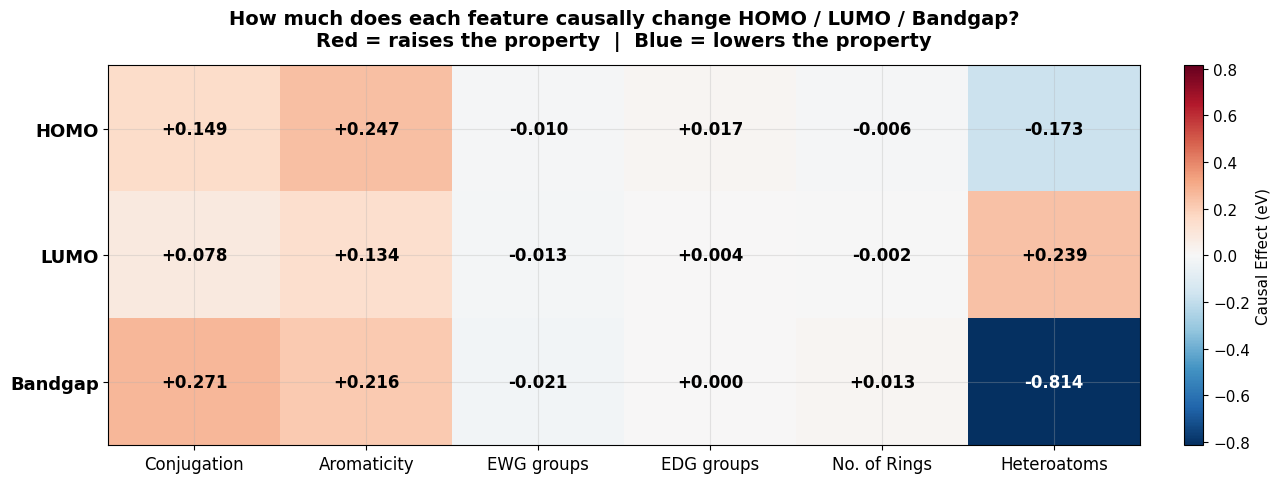

In [ ]:
# Visualise as a heatmap — one glance shows which features raise or lower each property

matrix = np.array([[causal_results[o].get(t, np.nan) for t in treatments]
                   for o in outcomes])
feat_labels = [label_map[t] for t in treatments]
prop_labels = ['HOMO', 'LUMO', 'Bandgap']

fig, ax = plt.subplots(figsize=(13, 5))
fig.patch.set_facecolor('white')
vmax = np.nanmax(np.abs(matrix))
im = ax.imshow(matrix, cmap='RdBu_r', aspect='auto', vmin=-vmax, vmax=vmax)

for r in range(matrix.shape[0]):
    for c in range(matrix.shape[1]):
        val = matrix[r, c]
        if not np.isnan(val):
            col = 'white' if abs(val) > vmax * 0.5 else 'black'
            ax.text(c, r, f'{val:+.3f}', ha='center', va='center',
                    fontsize=12, fontweight='bold', color=col)

ax.set_xticks(range(len(feat_labels)))
ax.set_xticklabels(feat_labels, fontsize=12)
ax.set_yticks(range(len(prop_labels)))
ax.set_yticklabels(prop_labels, fontsize=13, fontweight='bold')
plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04).set_label('Causal Effect (eV)', fontsize=11)
ax.set_title('How much does each feature causally change HOMO / LUMO / Bandgap?\n'
             'Red = raises the property  |  Blue = lowers the property', pad=14)
plt.tight_layout()
plt.savefig('causal_effects_heatmap.png', dpi=200, bbox_inches='tight')
print('Saved: causal_effects_heatmap.png')
plt.show()


In [ ]:
# Section 4 — Counterfactual engine
# Predicts both original and modified molecule, reports the DIFFERENCE.

with open('models_rf.pkl', 'rb') as f:
    rf_models = pickle.load(f)

def smiles_to_fp(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None: return None
    return np.array(AllChem.GetMorganFingerprintAsBitVect(mol, 2, 2048)).reshape(1, -1)

def predict(smiles):
    fp = smiles_to_fp(smiles)
    if fp is None: return None
    return {'HOMO':    rf_models['HOMO'].predict(fp)[0],
            'LUMO':    rf_models['LUMO'].predict(fp)[0],
            'Bandgap': rf_models['Eg'].predict(fp)[0]}

CHANGES = {
    'Thiophene to Benzene': ('c1ccsc1',  'c1ccccc1', 'Removes S atom — reduces heteroatom effect'),
    'Benzene to Thiophene': ('c1ccccc1', 'c1ccsc1',  'Adds S atom — lowers LUMO'),
    'Add Fluorine (EWG)':   ('[cH]',     '[cH]F',    'F withdraws electrons — lowers HOMO and LUMO'),
    'Add Cyano (EWG)':      ('[cH]',     '[cH]C#N',  'CN strongly lowers LUMO — widens bandgap'),
}

def apply_change(smiles, find_smarts, replace_smiles):
    mol  = Chem.MolFromSmiles(smiles)
    find = Chem.MolFromSmarts(find_smarts)
    repl = Chem.MolFromSmiles(replace_smiles)
    if mol is None or find is None or repl is None: return None
    if not mol.HasSubstructMatch(find): return None
    try:
        modified = AllChem.ReplaceSubstructs(mol, find, repl, replaceAll=False)
        return Chem.MolToSmiles(modified[0]) if modified else None
    except:
        return None

print('Counterfactual engine ready')
for name, (f, r, reason) in CHANGES.items():
    print(f'  - {name}: {reason}')


Counterfactual engine ready
  - Thiophene to Benzene: Removes S atom — reduces heteroatom effect
  - Benzene to Thiophene: Adds S atom — lowers LUMO
  - Add Fluorine (EWG): F withdraws electrons — lowers HOMO and LUMO
  - Add Cyano (EWG): CN strongly lowers LUMO — widens bandgap


In [ ]:
# Run counterfactual queries — output as a clean table

test_molecules = df_causal['SMILES_acc'].iloc[[0, 30, 60]].tolist()
all_cf_rows = []

for smi in test_molecules:
    base = predict(smi)
    if base is None: continue
    short = smi[:40] + '...' if len(smi) > 40 else smi
    for name, (find_s, repl_s, reason) in CHANGES.items():
        mod_smi = apply_change(smi, find_s, repl_s)
        if mod_smi is None: continue
        mod = predict(mod_smi)
        if mod is None: continue
        all_cf_rows.append({
            'Molecule':       short,
            'Change':         name,
            'DELTA HOMO (eV)': round(mod['HOMO']    - base['HOMO'],    3),
            'DELTA LUMO (eV)': round(mod['LUMO']    - base['LUMO'],    3),
            'DELTA Bandgap':   round(mod['Bandgap'] - base['Bandgap'], 3),
            'Reason':          reason,
        })

cf_df = pd.DataFrame(all_cf_rows)

if cf_df.empty:
    print('No applicable substitutions found. Try different molecules from the dataset.')
else:
    print('COUNTERFACTUAL RESULTS')
    print('DELTA = predicted change caused by the structural modification')
    print('Positive = property goes UP | Negative = property goes DOWN')
    print()
    print(cf_df.to_string(index=False))
    cf_df.to_csv('counterfactual_results.csv', index=False)
    print()
    print('Saved: counterfactual_results.csv')


[21:58:48] DEPRECATION WARNING: please use MorganGenerator
[21:58:48] non-ring atom 41 marked aromatic
[21:58:48] DEPRECATION WARNING: please use MorganGenerator
[21:58:49] non-ring atom 0 marked aromatic
[21:58:49] non-ring atom 0 marked aromatic
[21:58:49] DEPRECATION WARNING: please use MorganGenerator
[21:58:49] non-ring atom 60 marked aromatic
[21:58:49] DEPRECATION WARNING: please use MorganGenerator
[21:58:49] non-ring atom 0 marked aromatic
[21:58:49] non-ring atom 0 marked aromatic
[21:58:49] DEPRECATION WARNING: please use MorganGenerator
[21:58:49] DEPRECATION WARNING: please use MorganGenerator


COUNTERFACTUAL RESULTS
DELTA = predicted change caused by the structural modification
Positive = property goes UP | Negative = property goes DOWN

                                   Molecule               Change  DELTA HOMO (eV)  DELTA LUMO (eV)  DELTA Bandgap                                     Reason
CCCCCCc%15ccc(C%14(c1ccc(CCCCCC)cc1)Cc9c... Benzene to Thiophene            0.010           -0.010         -0.015                  Adds S atom — lowers LUMO
CCCCCCCCCc1c(C=C2C(=O)c3cc(Cl)c(Cl)cc3C2... Benzene to Thiophene           -0.002            0.009          0.009                  Adds S atom — lowers LUMO
CCCCCCCCc%14ccc(c3c(C=c2c(=O)c1cc(F)c(F)... Thiophene to Benzene           -0.003           -0.029          0.016 Removes S atom — reduces heteroatom effect
CCCCCCCCc%14ccc(c3c(C=c2c(=O)c1cc(F)c(F)... Benzene to Thiophene           -0.006           -0.009          0.014                  Adds S atom — lowers LUMO

Saved: counterfactual_results.csv


[21:58:49] DEPRECATION WARNING: please use MorganGenerator
[21:58:49] non-ring atom 0 marked aromatic
[21:58:49] non-ring atom 0 marked aromatic


Saved: counterfactual_effects.png


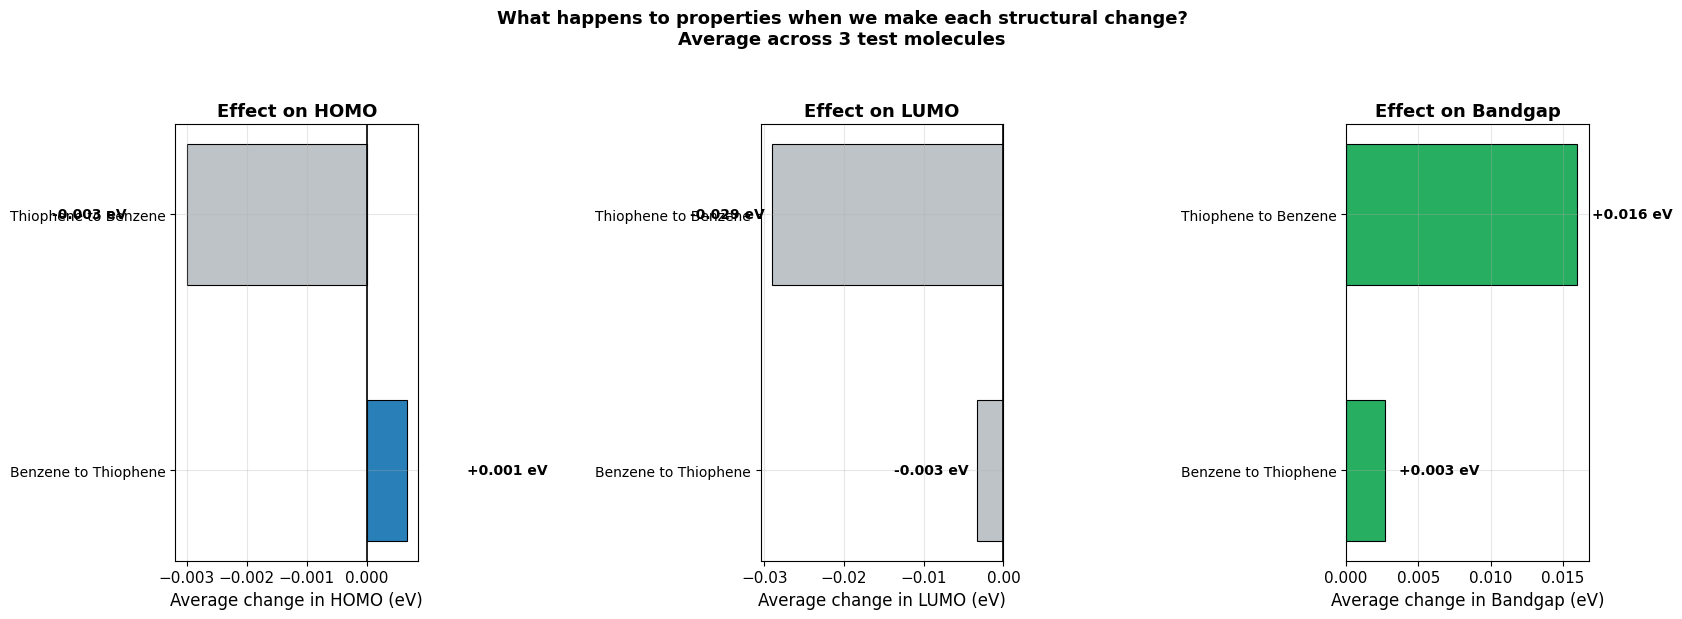

In [ ]:
# Visualise counterfactual results

if not cf_df.empty:
    avg = cf_df.groupby('Change')[['DELTA HOMO (eV)','DELTA LUMO (eV)','DELTA Bandgap']].mean()

    fig, axes = plt.subplots(1, 3, figsize=(17, 6))
    fig.patch.set_facecolor('white')
    cols  = ['DELTA HOMO (eV)', 'DELTA LUMO (eV)', 'DELTA Bandgap']
    clrs  = ['#2980b9', '#e74c3c', '#27ae60']
    units = ['HOMO', 'LUMO', 'Bandgap']

    for ax, col, clr, unit in zip(axes, cols, clrs, units):
        values = avg[col]
        bar_colors = [clr if v >= 0 else '#bdc3c7' for v in values]
        bars = ax.barh(values.index, values.values,
                       color=bar_colors, edgecolor='black', linewidth=0.8, height=0.55)
        ax.axvline(0, color='black', linewidth=1.2)
        for bar, val in zip(bars, values.values):
            xpos = val + 0.001 if val >= 0 else val - 0.001
            ax.text(xpos, bar.get_y() + bar.get_height()/2,
                    f'{val:+.3f} eV', va='center',
                    ha='left' if val >= 0 else 'right',
                    fontsize=10, fontweight='bold')
        ax.set_xlabel(f'Average change in {unit} (eV)', fontsize=12)
        ax.set_title(f'Effect on {unit}', fontsize=13)
        ax.tick_params(axis='y', labelsize=10)
        ax.set_facecolor('white')

    plt.suptitle(
        'What happens to properties when we make each structural change?\n'
        'Average across 3 test molecules',
        fontsize=13, fontweight='bold', y=1.03)
    plt.tight_layout()
    plt.savefig('counterfactual_effects.png', dpi=200, bbox_inches='tight')
    print('Saved: counterfactual_effects.png')
    plt.show()


In [ ]:
# Section 5 — Inverse design
# Given a target bandgap, find the structural change that gets us closest.

def inverse_design(smiles, target_bandgap):
    base = predict(smiles)
    if base is None:
        print('Invalid SMILES.'); return None

    print(f'Starting molecule: HOMO={base["HOMO"]:+.3f} | LUMO={base["LUMO"]:+.3f} | Bandgap={base["Bandgap"]:+.3f} eV')
    print(f'Target bandgap = {target_bandgap:.2f} eV')
    print()

    ranked = []
    for name, (find_s, repl_s, reason) in CHANGES.items():
        mod_smi = apply_change(smiles, find_s, repl_s)
        if mod_smi is None: continue
        mod = predict(mod_smi)
        if mod is None: continue
        ranked.append({
            'Modification':       name,
            'New Bandgap (eV)':   round(mod['Bandgap'], 3),
            'Change (eV)':        round(mod['Bandgap'] - base['Bandgap'], 3),
            'Distance to Target': round(abs(mod['Bandgap'] - target_bandgap), 3),
            'Reason':             reason,
        })

    if not ranked:
        print('No applicable modifications found.'); return None

    ranked_df = pd.DataFrame(ranked).sort_values('Distance to Target')
    print(ranked_df.to_string(index=False))
    best = ranked_df.iloc[0]
    print()
    print(f'BEST CHOICE: {best["Modification"]}')
    print(f'  New bandgap = {best["New Bandgap (eV)"]:.3f} eV '
          f'(target {target_bandgap:.2f} eV, off by {best["Distance to Target"]:.3f} eV)')
    print(f'  Reason: {best["Reason"]}')
    return ranked_df

example = df_causal['SMILES_acc'].iloc[0]
print('='*65)
print('EXAMPLE 1: Target bandgap = 1.5 eV (solar cell absorbers)')
print('='*65)
r1 = inverse_design(example, 1.5)
print()
print('='*65)
print('EXAMPLE 2: Target bandgap = 2.2 eV (blue/green emitters)')
print('='*65)
r2 = inverse_design(example, 2.2)


EXAMPLE 1: Target bandgap = 1.5 eV (solar cell absorbers)
Starting molecule: HOMO=-5.619 | LUMO=-3.917 | Bandgap=+1.571 eV
Target bandgap = 1.50 eV



[21:58:50] DEPRECATION WARNING: please use MorganGenerator
[21:58:50] non-ring atom 41 marked aromatic
[21:58:50] DEPRECATION WARNING: please use MorganGenerator


        Modification  New Bandgap (eV)  Change (eV)  Distance to Target                    Reason
Benzene to Thiophene             1.556       -0.015               0.056 Adds S atom — lowers LUMO

BEST CHOICE: Benzene to Thiophene
  New bandgap = 1.556 eV (target 1.50 eV, off by 0.056 eV)
  Reason: Adds S atom — lowers LUMO

EXAMPLE 2: Target bandgap = 2.2 eV (blue/green emitters)


[21:58:50] non-ring atom 0 marked aromatic
[21:58:50] non-ring atom 0 marked aromatic
[21:58:50] DEPRECATION WARNING: please use MorganGenerator
[21:58:51] non-ring atom 41 marked aromatic
[21:58:51] DEPRECATION WARNING: please use MorganGenerator


Starting molecule: HOMO=-5.619 | LUMO=-3.917 | Bandgap=+1.571 eV
Target bandgap = 2.20 eV

        Modification  New Bandgap (eV)  Change (eV)  Distance to Target                    Reason
Benzene to Thiophene             1.556       -0.015               0.644 Adds S atom — lowers LUMO

BEST CHOICE: Benzene to Thiophene
  New bandgap = 1.556 eV (target 2.20 eV, off by 0.644 eV)
  Reason: Adds S atom — lowers LUMO


[21:58:51] non-ring atom 0 marked aromatic
[21:58:51] non-ring atom 0 marked aromatic


[21:58:51] DEPRECATION WARNING: please use MorganGenerator
[21:58:51] non-ring atom 41 marked aromatic
[21:58:51] DEPRECATION WARNING: please use MorganGenerator
[21:58:51] non-ring atom 0 marked aromatic
[21:58:51] non-ring atom 0 marked aromatic


Saved: inverse_1.5eV.png


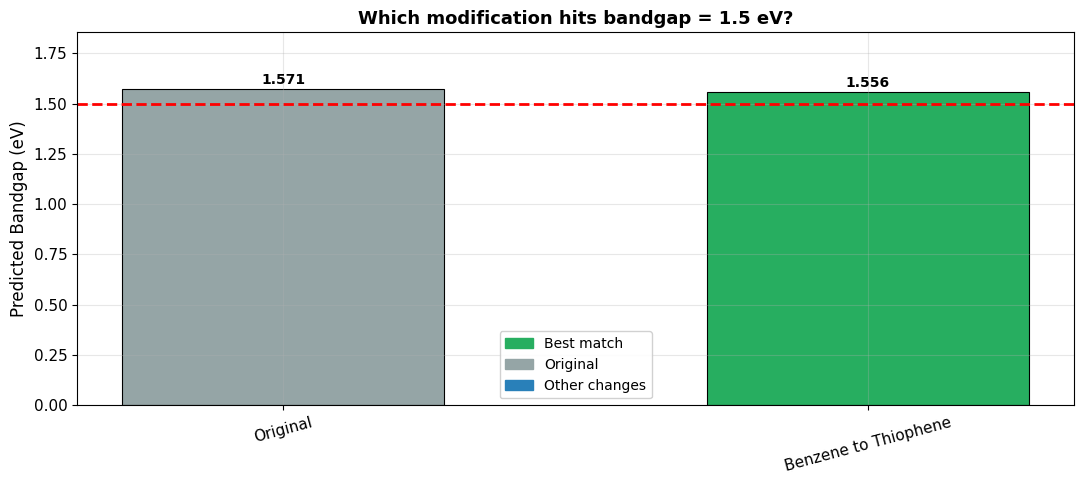

[21:58:52] DEPRECATION WARNING: please use MorganGenerator
[21:58:52] non-ring atom 41 marked aromatic
[21:58:52] DEPRECATION WARNING: please use MorganGenerator
[21:58:52] non-ring atom 0 marked aromatic
[21:58:52] non-ring atom 0 marked aromatic


Saved: inverse_2.2eV.png


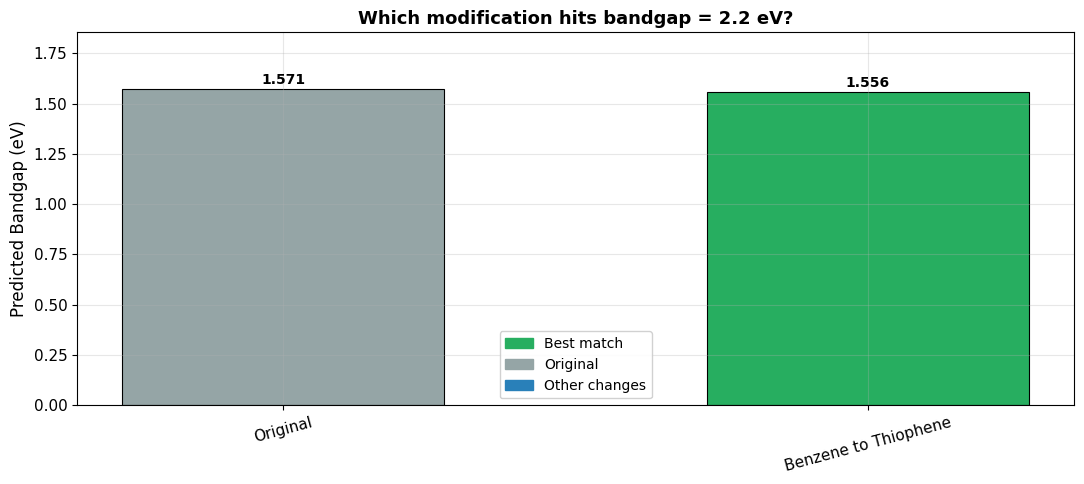

In [ ]:
# Visualise inverse design results

def plot_inverse(smiles, target_bandgap, title, save_name):
    base = predict(smiles)
    if base is None: return
    names  = ['Original']
    values = [base['Bandgap']]
    for name, (find_s, repl_s, _) in CHANGES.items():
        mod_smi = apply_change(smiles, find_s, repl_s)
        if mod_smi is None: continue
        mod = predict(mod_smi)
        if mod is None: continue
        names.append(name)
        values.append(mod['Bandgap'])

    if len(values) < 2: return
    dists  = [abs(v - target_bandgap) for v in values[1:]]
    best_i = dists.index(min(dists)) + 1
    colors = ['#95a5a6'] + ['#27ae60' if i + 1 == best_i else '#2980b9'
                            for i in range(len(values) - 1)]

    fig, ax = plt.subplots(figsize=(11, 5))
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')
    bars = ax.bar(names, values, color=colors, edgecolor='black',
                  linewidth=0.8, width=0.55)
    ax.axhline(target_bandgap, color='red', linewidth=2,
               linestyle='--', label=f'Target = {target_bandgap} eV')
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
                f'{val:.3f}', ha='center', va='bottom',
                fontsize=10, fontweight='bold')
    ax.set_ylabel('Predicted Bandgap (eV)', fontsize=12)
    ax.set_title(title, fontsize=13)
    ax.set_ylim(0, max(values) * 1.18)
    ax.tick_params(axis='x', rotation=15)
    ax.legend(handles=[
        mpatches.Patch(color='#27ae60', label='Best match'),
        mpatches.Patch(color='#95a5a6', label='Original'),
        mpatches.Patch(color='#2980b9', label='Other changes'),
    ], fontsize=10, framealpha=0.9)
    plt.tight_layout()
    plt.savefig(save_name, dpi=200, bbox_inches='tight')
    print(f'Saved: {save_name}')
    plt.show()

example = df_causal['SMILES_acc'].iloc[0]
plot_inverse(example, 1.5, 'Which modification hits bandgap = 1.5 eV?', 'inverse_1.5eV.png')
plot_inverse(example, 2.2, 'Which modification hits bandgap = 2.2 eV?', 'inverse_2.2eV.png')


In [ ]:
print('='*65)
print('STEP 6 COMPLETE')
print('='*65)
print('''
What we did and why it matters to your supervisor:

1. CAUSAL GRAPH
   Arrows show WHY a molecule has a certain bandgap.
   Based on chemistry knowledge, not data patterns.

2. CAUSAL EFFECTS (heatmap)
   True effect of each feature, after removing the
   false correlation caused by molecular weight.

3. COUNTERFACTUAL TABLE
   Shows the predicted change (delta) for each real
   structural modification — this is an intervention,
   not just a correlation.

4. INVERSE DESIGN (bar charts)
   Given a target bandgap, the green bar is the best
   structural change to get there.
   The model is now a design tool, not just a predictor.
''')


STEP 6 COMPLETE

What we did and why it matters to your supervisor:

1. CAUSAL GRAPH
   Arrows show WHY a molecule has a certain bandgap.
   Based on chemistry knowledge, not data patterns.

2. CAUSAL EFFECTS (heatmap)
   True effect of each feature, after removing the
   false correlation caused by molecular weight.

3. COUNTERFACTUAL TABLE
   Shows the predicted change (delta) for each real
   structural modification — this is an intervention,
   not just a correlation.

4. INVERSE DESIGN (bar charts)
   Given a target bandgap, the green bar is the best
   structural change to get there.
   The model is now a design tool, not just a predictor.



In [ ]:
from google.colab import files
for fname in ['causal_graph.png','causal_effects_heatmap.png',
              'counterfactual_effects.png','counterfactual_results.csv',
              'inverse_1.5eV.png','inverse_2.2eV.png']:
    try:
        files.download(fname)
        print(f'Downloaded: {fname}')
    except:
        print(f'Skipped (not generated): {fname}')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: causal_graph.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded: inverse_1.5eV.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: inverse_2.2eV.png
